# MalSem-Decon: 第一階段弱監督流程

這份 notebook 的目標，是在只有 **大量一般 FB 貼文**、**社團/粉專名稱** 與 **少量種子關鍵字** 的前提下，先做出可執行的第一階段弱監督流程。

## 這份 notebook 在做什麼
- 先用社團名稱做啟發式風險分桶，縮小可能的搜尋範圍。
- 再用負面種子詞對貼文做弱標註，建立高風險樣本與對照組樣本。
- 接著比較兩組貼文的詞頻差異，找出可能的惡意語意特徵詞。
- 最後把貼文向量化，做異常檢測與異常群錨點詞抽取。

## 目前資料限制
- `nodes_page_1hop.csv` 與 `time_line.xlsx` 目前沒有可直接對齊的 `page_id/profile_id`，因此無法穩定地把「某社團」直接接到「該社團的所有貼文」。
- 所以這裡採用的是 **代理式流程**：名稱風險分桶 + 貼文內容弱監督，而不是嚴格的社團貼文配對分析。

## 分析流程
1. 名稱啟發式過濾：用社團名稱命中風險詞與一般詞，建立高風險桶與對照組桶。
2. 種子詞弱標註：用 `negative_keywords.txt` 去標記貼文中的高風險樣本。
3. 對比詞分析：用 log-odds 找出高風險貼文相較於對照組特別突出的詞。
4. 向量化與異常檢測：將貼文投影到低維空間後，用 Isolation Forest 找異常點。
5. 錨點詞抽取：對高風險異常群做 c-TF-IDF，幫助理解每一群在說什麼。


In [32]:
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

# 專案中的資料目錄與隨機種子。
DATA_DIR = Path("./Data")
RANDOM_STATE = 42

# 負面種子詞：來自既有的 negative keyword 清單。
RISK_KEYWORDS = (
    pd.read_csv(DATA_DIR / "negative_keywords.txt", header=None, encoding="utf-8")[0]
    .dropna()
    .astype(str)
    .tolist()
)

# 一般內容種子詞：這裡故意選比較生活化、非惡意語境的詞，作為對照組來源。
BENIGN_KEYWORDS = [
    "美食", "料理", "運動", "健身", "旅遊", "寵物", "貓", "狗",
    "攝影", "音樂", "電影", "閱讀", "親子", "露營", "烘焙", "手作",
]

# 常見但辨識力弱的詞，後面切詞時會盡量排除，避免雜訊過高。
STOP_TERMS = {
    "今天", "分享", "可以", "一起", "自己", "這個", "如果", "因為", "就是", "不是",
    "一個", "你們", "我們", "他們", "真的", "看到", "知道", "感謝", "希望", "喜歡",
    "支持", "朋友", "留言", "歡迎", "最新", "大家", "需要", "使用", "生活", "影片",
    "照片", "粉絲", "覺得", "是否", "開始", "之後", "直接", "相關", "提供", "目前",
    "收到", "免費", "時間", "內容", "文章", "連結", "作者", "社團", "社群",
}

# 中文與英文混雜內容常見，因此用正則先抓出中英文區塊。
CJK_OR_ALNUM = re.compile(r"[\u4e00-\u9fff]+|[a-z0-9_]+")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
WHITESPACE_RE = re.compile(r"\s+")

# 視覺化設定：指定常見中文字型，避免圖表中文字缺字。
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


## 輔助函式

這一段把後面會反覆使用的資料前處理、切詞、抽樣與統計函式集中起來。

幾個關鍵設計如下：
- 不依賴 `openpyxl`：直接解析 `xlsx` 底層 XML，避免環境缺套件時 notebook 無法執行。
- 不依賴外部分詞器：中文內容先做 2-gram 到 4-gram 切片，作為簡化版切詞策略。
- 先做弱監督，不直接做監督式分類：因為目前沒有人工標註好的惡意/非惡意標籤。


In [33]:
def normalize_text(text):
    # 統一成小寫、移除網址與多餘空白，讓後續比對與向量化更穩定。
    text = "" if text is None else str(text)
    text = text.replace("\ufeff", " ")
    text = URL_RE.sub(" ", text.lower())
    text = re.sub(r"[\r\n\t]+", " ", text)
    return WHITESPACE_RE.sub(" ", text).strip()


def tokenize_mixed(text):
    # 不使用 jieba，改用簡化版切詞。
    # 英文保留整個 token，中文則拆成 2~4 gram，兼顧可執行性與基本語意辨識力。
    text = normalize_text(text)
    tokens = []

    for block in CJK_OR_ALNUM.findall(text):
        if re.fullmatch(r"[a-z0-9_]+", block):
            if len(block) >= 2 and block not in STOP_TERMS:
                tokens.append(block)
            continue

        if len(block) < 2:
            continue

        upper = min(4, len(block))
        for n in range(2, upper + 1):
            for i in range(len(block) - n + 1):
                term = block[i : i + n]
                if term not in STOP_TERMS:
                    tokens.append(term)

    return tokens


def keyword_hits(text, keywords):
    # 回傳一段文字中實際命中的關鍵字，方便後面做可解釋的弱標註。
    return [keyword for keyword in keywords if keyword in text]


def read_timeline_xlsx(path):
    # 直接解析 xlsx 的 XML，避免缺少 openpyxl 時讀檔失敗。
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    rows = []

    def cell_text(cell):
        inline = cell.find("a:is", ns)
        value = cell.find("a:v", ns)
        return "".join(inline.itertext()) if inline is not None else (value.text if value is not None else "")

    with zipfile.ZipFile(path) as zf:
        root = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        sheet_rows = root.find("a:sheetData", ns)
        header_map = {}

        for row_idx, row in enumerate(sheet_rows):
            row_values = {}
            for cell in row:
                ref = cell.attrib.get("r", "")
                col = "".join(ch for ch in ref if ch.isalpha())
                row_values[col] = cell_text(cell)

            if row_idx == 0:
                header_map = row_values
                continue

            rows.append({header_map.get(col, col): value for col, value in row_values.items()})

    return pd.DataFrame(rows)


def sample_bucket(df, label, frac=0.10, min_n=50, max_n=250):
    # 先用小樣本快速驗證流程。
    # 規則：取該弱標籤資料的 10%，但至少 50 筆、最多 250 筆。
    subset = df[df["weak_label"] == label]
    if subset.empty:
        return subset.copy()

    n = max(min_n, int(np.ceil(len(subset) * frac)))
    n = min(len(subset), max_n, n)
    return subset.sample(n=n, random_state=RANDOM_STATE).copy()


def compute_log_odds(positive_texts, negative_texts):
    # 比較高風險組與對照組的 token 分布差異。
    # log-odds 越高，代表該詞越偏向出現在高風險組。
    vectorizer = CountVectorizer(
        tokenizer=tokenize_mixed,
        token_pattern=None,
        lowercase=False,
        min_df=2,
        max_features=5000,
    )
    all_texts = pd.Series(positive_texts).tolist() + pd.Series(negative_texts).tolist()
    matrix = vectorizer.fit_transform(all_texts)

    pos_n = len(positive_texts)
    pos_counts = matrix[:pos_n].sum(axis=0).A1
    neg_counts = matrix[pos_n:].sum(axis=0).A1
    alpha = 0.5

    scores = np.log((pos_counts + alpha) / (pos_counts.sum() + alpha * len(pos_counts)))
    scores -= np.log((neg_counts + alpha) / (neg_counts.sum() + alpha * len(neg_counts)))

    summary = pd.DataFrame(
        {
            "term": vectorizer.get_feature_names_out(),
            "log_odds": scores,
            "positive_count": pos_counts,
            "negative_count": neg_counts,
        }
    )

    # 至少出現 3 次以上，避免極低頻詞把排序洗掉。
    return summary[(summary["positive_count"] + summary["negative_count"]) >= 3].sort_values("log_odds", ascending=False)


def compute_ctfidf(cluster_df):
    # 對異常群做 cluster-level TF-IDF。
    # 這一步的目的不是分類，而是幫每個群抽出最有代表性的錨點詞。
    grouped = cluster_df.groupby("cluster")["text"].apply(lambda s: " ".join(s)).reset_index()

    vectorizer = CountVectorizer(
        tokenizer=tokenize_mixed,
        token_pattern=None,
        lowercase=False,
        min_df=1,
        max_features=3000,
    )
    matrix = vectorizer.fit_transform(grouped["text"])
    if matrix.shape[1] == 0:
        return pd.DataFrame(columns=["cluster", "term", "score"])

    tf = matrix.toarray().astype(float)
    tf = tf / np.clip(tf.sum(axis=1, keepdims=True), 1e-9, None)

    doc_freq = (matrix > 0).sum(axis=0).A1
    idf = np.log(1 + len(cluster_df) / (doc_freq + 1))
    scores = tf * idf
    terms = np.array(vectorizer.get_feature_names_out())

    rows = []
    for row_idx, cluster_id in enumerate(grouped["cluster"]):
        top_idx = np.argsort(scores[row_idx])[::-1][:10]
        for term_idx in top_idx:
            rows.append(
                {
                    "cluster": int(cluster_id),
                    "term": terms[term_idx],
                    "score": float(scores[row_idx, term_idx]),
                }
            )

    return pd.DataFrame(rows)


## Stage 1. 社團名稱的啟發式過濾

這一步處理的是 `nodes_page_1hop.csv`。

### 想回答的問題
- 哪些名稱看起來比較可能與惡意語意相關？
- 哪些名稱明顯是一般生活內容，可以拿來當對照組？

### 做法
- 只保留 `category` 為 `社群` 或 `Community` 的頁面。
- 用 `RISK_KEYWORDS` 命中名稱，命中就進 `high_risk`。
- 沒命中風險詞，但命中一般詞的，進 `control`。
- 都沒命中的暫時放進 `other`。

### 輸出如何看
- `page_bucket_summary`：三個桶各有多少名稱。
- `page_seed_frequency`：哪些風險關鍵字最常出現在名稱裡。
- 後面的樣本表格：幫你人工檢查這個分桶是否合理。


In [34]:
# 只保留較接近「社團」的來源，避免把一般粉專或商家都混進名稱啟發式過濾。
pages = pd.read_csv(
    DATA_DIR / "nodes_page_1hop.csv",
    encoding="utf-8",
    usecols=["page_id:ID(Page)", "category", "name"],
)
club_pages = pages[pages["category"].astype(str).isin(["社群", "Community"])].copy()
club_pages["name"] = club_pages["name"].fillna("").astype(str)

# 風險命中數越高，代表名稱中帶有越多敏感語意。
club_pages["risk_hits"] = club_pages["name"].map(lambda text: keyword_hits(text, RISK_KEYWORDS))
club_pages["risk_score"] = club_pages["risk_hits"].str.len()

# 一般詞命中用來建立對照組桶，而不是直接判定內容安全。
club_pages["benign_hits"] = club_pages["name"].map(lambda text: keyword_hits(text, BENIGN_KEYWORDS))
club_pages["benign_score"] = club_pages["benign_hits"].str.len()

club_pages["page_bucket"] = np.select(
    [club_pages["risk_score"] > 0, club_pages["benign_score"] > 0],
    ["high_risk", "control"],
    default="other",
)

page_bucket_summary = club_pages["page_bucket"].value_counts().rename_axis("bucket").reset_index(name="count")
page_seed_frequency = pd.DataFrame(
    [
        {
            "keyword": keyword,
            "club_hits": int(club_pages["name"].str.contains(re.escape(keyword), na=False).sum()),
        }
        for keyword in RISK_KEYWORDS
    ]
).sort_values("club_hits", ascending=False)

print("目前 time_line.xlsx 與 nodes_page_1hop.csv 沒有可直接 merge 的 profile/page id。")
print("因此這份 notebook 先做『社團名稱風險分桶』，再用貼文內容做弱監督採樣與異常檢測。")

display(page_bucket_summary)
display(page_seed_frequency.head(15))
display(
    club_pages.loc[club_pages["page_bucket"] == "high_risk", ["name", "risk_hits", "risk_score"]].head(10)
)
display(
    club_pages.loc[club_pages["page_bucket"] == "control", ["name", "benign_hits", "benign_score"]].head(10)
)


目前 time_line.xlsx 與 nodes_page_1hop.csv 沒有可直接 merge 的 profile/page id。
因此這份 notebook 先做『社團名稱風險分桶』，再用貼文內容做弱監督採樣與異常檢測。


,bucket,count
0,other,138868
1,control,4776
2,high_risk,546


,keyword,club_hits
9,精品,316
16,自救會,48
13,致富,27
12,厭世,26
10,娛樂城,23
0,貸款,22
27,運彩,18
14,借款,15
21,酒店,14
29,博弈,12


,name,risk_hits,risk_score
19808,機師娘趴趴走-歐洲精品代購,[精品],1
34107,全方位小築翡翠珠寶精品,[精品],1
38301,大Ying精品百貨,[精品],1
46611,PM2.5 自救會：資訊應公開，拒絕髒空氣,[自救會],1
48590,婦女小額貸款 - 提供免費諮詢，快速媒合適合您的銀行專案,[貸款],1
66384,厭世頹＆幸福巧。我的貓生。後來還有Neko。,[厭世],1
75437,Hailey&Me精品童裝,[精品],1
84887,中信娛樂城,[娛樂城],1
85006,小仙女時尚精品代購Fées for you,[精品],1
99028,Hope童趣精品,[精品],1


,name,benign_hits,benign_score
191,我們用電影寫日記,[電影],1
280,貓狗俱樂部,"[貓, 狗]",2
590,國際狗語日報 X 百靈果News,[狗],1
881,走吧！來去日本旅遊、自由行！,[旅遊],1
960,全球健身指南,[健身],1
975,旅行貓日記跟著辛巴&球玩台灣,[貓],1
1539,洋洋食堂之放閃料理家,[料理],1
1975,運動女神正能量激勵聯盟,[運動],1
2116,竹北美食散步,[美食],1
2924,運動賽事報,[運動],1


## Stage 2. 種子詞弱監督貼文標註

這一步處理的是 `time_line.xlsx` 裡的貼文內容。

### 想回答的問題
- 在大量未標註貼文中，哪些貼文可以先被視為「高風險候選」？
- 哪些貼文可以當作一般內容對照組？

### 做法
- 合併 `content`、`share_content`、`attachment_title`、`attachment_description`。
- 用風險詞命中結果產生 `risk_seed_score`。
- 用一般詞命中結果產生 `benign_seed_score`。
- 若命中風險詞，標成 `risk_seed`；否則若命中一般詞，標成 `benign_seed`；其餘標成 `unlabeled`。

### 輸出如何看
- `post_label_summary`：目前三種弱標籤各有多少貼文。
- 後面兩個表格：人工檢查高風險樣本與一般樣本是否合理。


In [35]:
# 讀貼文資料，並把多個可能的文字欄位整合成單一 text 欄位。
posts = read_timeline_xlsx(DATA_DIR / "time_line.xlsx")
text_columns = ["content", "share_content", "attachment_title", "attachment_description"]

for column in text_columns:
    if column not in posts:
        posts[column] = ""

posts[text_columns] = posts[text_columns].fillna("").astype(str)
posts["text"] = posts[text_columns].agg(" ".join, axis=1).map(normalize_text)
posts = posts[posts["text"].str.len() > 0].copy()

# 風險種子詞命中：作為弱監督的正向候選。
posts["risk_hits"] = posts["text"].map(lambda text: keyword_hits(text, RISK_KEYWORDS))
posts["risk_seed_score"] = posts["risk_hits"].str.len()

# 一般詞命中：作為對照組候選。
posts["benign_hits"] = posts["text"].map(lambda text: keyword_hits(text, BENIGN_KEYWORDS))
posts["benign_seed_score"] = posts["benign_hits"].str.len()

# 弱標籤規則：先看風險，再看一般。這是故意設計，避免雙命中時被錯放到 benign。
posts["weak_label"] = np.select(
    [posts["risk_seed_score"] > 0, posts["benign_seed_score"] > 0],
    ["risk_seed", "benign_seed"],
    default="unlabeled",
)

post_label_summary = posts["weak_label"].value_counts().rename_axis("label").reset_index(name="count")

display(post_label_summary)
display(
    posts.loc[posts["weak_label"] == "risk_seed", ["risk_hits", "risk_seed_score", "text"]]
    .sort_values("risk_seed_score", ascending=False)
    .head(10)
)
display(
    posts.loc[posts["weak_label"] == "benign_seed", ["benign_hits", "benign_seed_score", "text"]]
    .sort_values("benign_seed_score", ascending=False)
    .head(10)
)


,label,count
0,unlabeled,35305
1,benign_seed,2435
2,risk_seed,329


,risk_hits,risk_seed_score,text
69500,"[貸款, 信貸, 債務, 借款, 二胎, 強力過件]",6,當天急用❗️ 快速播款❗️ ➡證件借可分期10萬內 30分審核 ➡條件：20萬 有工作 \ ...
76692,"[貸款, 八大, 全額, 強力過件]",4,2019年honda hr-v 1.8 -s 版 國內小型跨界休旅車 超高cp值+融合實用性...
76698,"[貸款, 八大, 全額, 強力過件]",4,🚗 2014年 mazda 馬5 尊爵版｜7人座家庭好幫手！ 甜甜價~售21萬8千 ✨ 雙側...
76682,"[貸款, 八大, 全額, 強力過件]",4,2021 中華-cmc zinger 自排 2.4l 網路價😍: 33萬8千 !!! 賺錢車...
76706,"[貸款, 八大, 全額, 強力過件]",4,2019年mazda cx-5 旗艦版🎊流線有型 百萬休旅美車👍 改可調式避震器🔸改排氣管🔸...
76705,"[貸款, 八大, 全額, 強力過件]",4,2018年#honda #本田 #cr-v s 百萬渦輪省油省稅車 網路甜甜價:59.8萬😍...
76704,"[貸款, 八大, 全額, 強力過件]",4,🚗 2020年三菱zinger 🌟 工作與家庭，一車搞定！ ✨ 只跑11萬公里，狀況優越！ ...
76703,"[貸款, 八大, 全額, 強力過件]",4,2019年mazda cx-5 旗艦版🎊流線有型 百萬休旅美車👍 改可調式避震器🔸改排氣管🔸...
76701,"[貸款, 八大, 全額, 強力過件]",4,🚗 2023年nissan kicks 旗艦版現正熱賣中！ 🔥 限時優惠，錯過不再！( 只跑...
76699,"[貸款, 八大, 全額, 強力過件]",4,2017年#honda #本田 #cr-v s 百萬省油省稅車 網路甜甜價:52萬8千💥 h...


,benign_hits,benign_seed_score,text
42350,"[美食, 料理, 健身, 貓, 親子]",5,【什麼是文案該有的銷售思維？】3517 字。 常有電商老闆跟我抱怨，說自家行銷寫的文案，都沒...
13639,"[美食, 運動, 攝影, 音樂]",4,身為一枚道地台媽， 當然抗拒不了地方小吃的誘惑！ 幾乎全年無休逢甲夜市，永遠在那！ 雖然喜歡...
10071,"[貓, 攝影, 音樂, 閱讀]",4,影片拍起來 #影片行銷 一次就上手☝️ 你是不是⋯ 想幫自家品牌拍一支高質感宣傳影片❓ 想知...
6709,"[美食, 寵物, 音樂, 手作]",4,這麼精彩的音樂市集不來真是太可惜了！！！ 這週六這週六這週六下午2點開始 歡迎在台北有空的你...
40233,"[美食, 攝影, 音樂, 電影]",4,bazaar 幹大事特展 bazaar 跨越30．幹大事特展 - 測出最適合你的時尚雜誌工作...
6726,"[貓, 狗, 烘焙, 手作]",4,🐈 五喵新春出擊 🐈 捕捉闆娘過年市集擺攤現場 認真的闆娘❤️ 瞬間變成小幫手一枚也覺得很榮...
3954,"[寵物, 貓, 狗]",3,麻煩大家把貓友都邀請進來，或幫忙高調這篇文章... 謝謝記者朋友跟公眾人物幫忙聲援，上新聞了...
43225,"[美食, 旅遊, 電影]",3,完美複製 去日本要朝聖~ 最想打卡的日本動漫景點是… - juksy 街星 到日本旅遊，除了...
47558,"[美食, 料理, 音樂]",3,hi！沖繩 基隆將辦島嶼生活節 | 聯合新聞網 曾有全台最早最大琉球聚落的基隆和平島公園，將...
47307,"[美食, 料理, 旅遊]",3,不知道在哪看到他們家的餐，感覺很不錯。#新北景點 #新北美食 #新北旅遊 #新北美食推薦 #...


## Stage 3. 高風險與一般貼文的對比詞分析

這一步的目的，是從弱標註出來的兩組貼文中，找出 **高風險組特別常出現，但對照組不常出現** 的詞。

### 做法
- 先從 `risk_seed` 與 `benign_seed` 各抽 10% 左右的小樣本，快速做流程驗證。
- 用 `compute_log_odds()` 比較兩組文字分布差異。
- 取出排序前面的詞，作為目前資料下可能的高風險語意特徵。

### 輸出如何看
- `top_log_odds`：高風險樣本相對於對照組最偏高的詞。
- `candidate_terms`：把原始種子詞排掉後，留下可能可擴充的候選詞。
- 條圖：幫你快速看哪些詞最突出。


,label,count
0,risk_seed,300
1,benign_seed,300


,term,log_odds,positive_count,negative_count
4257,貸款,5.130190,207,0
4278,賞車,4.711384,136,0
710,保證實,4.658740,129,0
1807,實車,4.424922,102,0
711,保證實車,4.405217,100,0
4191,證實車,4.405217,100,0
4196,證無,4.395217,99,0
713,保證無,4.395217,99,0
4658,酒店,4.343659,94,0
1295,可協助,4.195662,81,0


,term,log_odds,positive_count,negative_count
4278,賞車,4.711384,136,0
710,保證實,4.658740,129,0
1807,實車,4.424922,102,0
711,保證實車,4.405217,100,0
4191,證實車,4.405217,100,0
4196,證無,4.395217,99,0
713,保證無,4.395217,99,0
1295,可協助,4.195662,81,0
1294,可協,4.195662,81,0
1312,可配合,4.007187,67,0


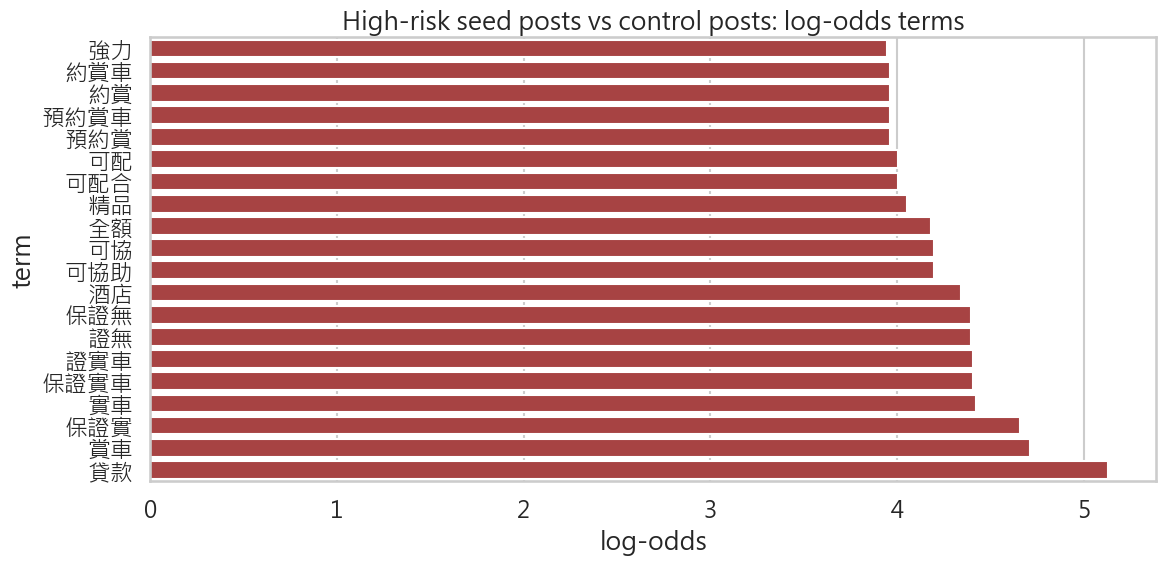

In [36]:
# 依照第一階段規劃，先抽 10% 的高風險貼文與對照組貼文做快速對比。
risk_sample = sample_bucket(posts, "risk_seed", frac=1.0, min_n=50, max_n=300)

# 對照組另外再保證「沒有命中風險詞」，避免混入偽陽性樣本。
control_source = posts[posts["risk_seed_score"] == 0].copy()
control_sample = sample_bucket(control_source, "benign_seed", frac=1.0, min_n=50, max_n=300)

analysis_posts = pd.concat([risk_sample, control_sample], ignore_index=True)
analysis_summary = analysis_posts["weak_label"].value_counts().rename_axis("label").reset_index(name="count")

log_odds_df = compute_log_odds(risk_sample["text"], control_sample["text"])
top_log_odds = log_odds_df.head(20).copy()

# 把已知種子詞排掉後，較容易看到潛在的新候選詞。
candidate_terms = log_odds_df.loc[~log_odds_df["term"].isin(RISK_KEYWORDS)].head(50).copy()

display(analysis_summary)
display(top_log_odds)
display(candidate_terms)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_log_odds.iloc[::-1], x="log_odds", y="term", color="#b83232")
plt.title("High-risk seed posts vs control posts: log-odds terms")
plt.xlabel("log-odds")
plt.ylabel("term")
plt.tight_layout()
plt.show()


## Stage 4. 向量化與異常檢測

這一步開始不只看關鍵字，而是看貼文在整體語意空間中的位置。

### 做法
- 用 TF-IDF 把貼文轉成向量。
- 用 SVD 降維到較小的空間，方便可視化與後續異常檢測。
- 用 `benign_seed` 當作相對正常的參考分布，訓練 `IsolationForest`。
- 對所有分析貼文計算 anomaly score，分數越高代表越偏離一般內容。

### 輸出如何看
- 散點圖：看高風險樣本與一般樣本在低維空間的分布。
- `is_anomaly = True` 的表格：優先檢查的異常貼文候選。


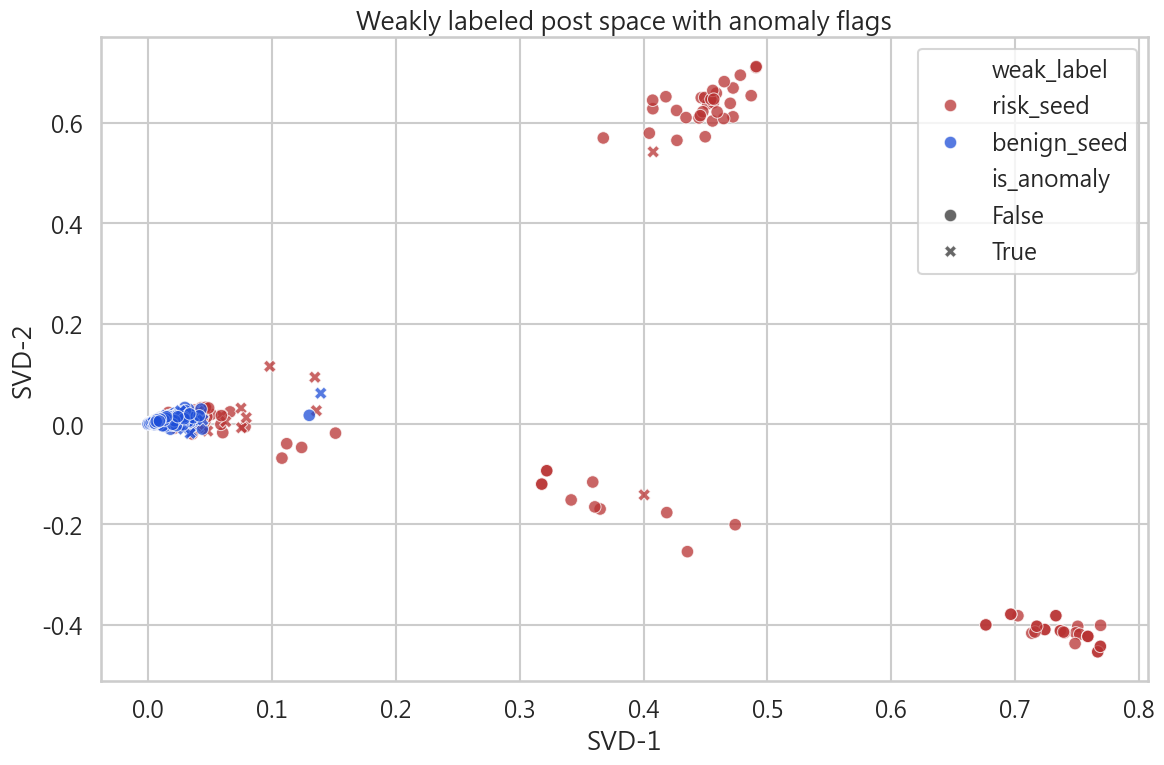

,weak_label,risk_hits,anomaly_score,text
461,benign_seed,[],0.526679,𝐑𝐞𝐜𝐨𝐫𝐝 𝐋𝐢𝐟𝐞- 𝐇𝐨𝐧𝐠𝐤𝐨𝐧𝐠 🇭🇰 #香港 #旅遊 #九龍 #荃灣 #金鐘#出...
514,benign_seed,[],0.526679,𝐑𝐞𝐜𝐨𝐫𝐝 𝐋𝐢𝐟𝐞- 𝐇𝐨𝐧𝐠𝐤𝐨𝐧𝐠 🇭🇰 #香港 #旅遊 #九龍 #荃灣 #金鐘#出...
495,benign_seed,[],0.521823,3/22強勢來襲 加入再送3月免費練功豪禮 #創角後直接送１０００斗內額度 #加碼贊助鑽石1...
492,benign_seed,[],0.521823,3/22強勢來襲 加入再送3月免費練功豪禮 #創角後直接送１０００斗內額度 #加碼贊助鑽石1...
523,benign_seed,[],0.516461,中砂員工旅遊第二站 ￼吃到飽喝到吐的喜酒🤣
185,risk_seed,[精品],0.515440,直播回顧直接從23:00 分進入重點 #讓你擁有賓士不是夢想 #闆爸發財車cla200sb抽...
237,risk_seed,[精品],0.515440,直播回顧直接從23:00 分進入重點 #讓你擁有賓士不是夢想 #闆爸發財車cla200sb抽...
550,benign_seed,[],0.509541,呂昇達老師團購 ★ 7/23 - 8/2 ★ 山崎家電 (1) 三款新色高效專業抬頭式攪拌機...
104,risk_seed,[精品],0.509263,發瘋啦！回饋6台！免費iphone14給大家！ 顏色可以任選但是如果缺貨就不能強求囉 ! 立...
29,risk_seed,[精品],0.509263,發瘋啦！回饋6台！免費iphone14給大家！ 顏色可以任選但是如果缺貨就不能強求囉 ! 立...


In [37]:
# TF-IDF：把每篇貼文表示成一個稀疏向量。
vectorizer = TfidfVectorizer(
    tokenizer=tokenize_mixed,
    token_pattern=None,
    lowercase=False,
    min_df=2,
    max_df=0.85,
    max_features=5000,
    sublinear_tf=True,
)
tfidf_matrix = vectorizer.fit_transform(analysis_posts["text"])

# 用 SVD 降維，讓貼文可以投影到較低維空間。
n_components = max(2, min(50, tfidf_matrix.shape[1] - 1))
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
reduced = svd.fit_transform(tfidf_matrix)

analysis_posts["svd_1"] = reduced[:, 0]
analysis_posts["svd_2"] = reduced[:, 1]

# 用 benign_seed 近似「正常內容分布」，再看哪些貼文明顯偏離。
isolation_forest = IsolationForest(contamination=0.20, random_state=RANDOM_STATE)
isolation_forest.fit(reduced[analysis_posts["weak_label"].eq("benign_seed")])

# score_samples 越小通常越異常，這裡取負號讓分數越大越容易閱讀。
analysis_posts["anomaly_score"] = -isolation_forest.score_samples(reduced)
analysis_posts["is_anomaly"] = isolation_forest.predict(reduced) == -1

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=analysis_posts,
    x="svd_1",
    y="svd_2",
    hue="weak_label",
    style="is_anomaly",
    palette={"risk_seed": "#b83232", "benign_seed": "#1d4ed8"},
    alpha=0.75,
)
plt.title("Weakly labeled post space with anomaly flags")
plt.xlabel("SVD-1")
plt.ylabel("SVD-2")
plt.tight_layout()
plt.show()

display(
    analysis_posts.loc[analysis_posts["is_anomaly"], ["weak_label", "risk_hits", "anomaly_score", "text"]]
    .sort_values("anomaly_score", ascending=False)
    .head(12)
)


## Stage 5. 高風險異常群的錨點詞抽取

前一步只知道哪些貼文看起來異常，這一步要進一步回答：**這些異常貼文大概分成哪幾類語意？**

### 做法
- 只保留 `risk_seed` 且 `is_anomaly = True` 的貼文。
- 若數量足夠，用 KMeans 先切成少量群集。
- 對每個群做 c-TF-IDF，抽出該群最有代表性的詞。

### 輸出如何看
- `anchor_terms`：每一群的代表詞。
- `risk_anomalies`：每群中的實際貼文樣本，方便人工驗證是否真的是同一類概念。


In [38]:
# 只分析「高風險種子貼文」中的異常點，避免一般內容主導群集結果。
risk_anomalies = analysis_posts.loc[
    analysis_posts["is_anomaly"] & analysis_posts["weak_label"].eq("risk_seed")
].copy()

# 這裡只切少量群，目的是快速看出主要異常概念，而不是追求精細分群。
if len(risk_anomalies) >= 3:
    cluster_count = min(3, len(risk_anomalies))
    kmeans = KMeans(n_clusters=cluster_count, random_state=RANDOM_STATE, n_init=10)
    risk_anomalies["cluster"] = kmeans.fit_predict(reduced[risk_anomalies.index.to_numpy()])
elif len(risk_anomalies) > 0:
    risk_anomalies["cluster"] = 0
else:
    risk_anomalies["cluster"] = pd.Series(dtype=int)

anchor_terms = (
    compute_ctfidf(risk_anomalies)
    if len(risk_anomalies) > 0
    else pd.DataFrame(columns=["cluster", "term", "score"])
)

display(anchor_terms.groupby("cluster").head(8) if not anchor_terms.empty else anchor_terms)
display(
    risk_anomalies[["cluster", "risk_hits", "anomaly_score", "text"]]
    .sort_values(["cluster", "anomaly_score"], ascending=[True, False])
    .head(15)
)


,cluster,term,score
0,0,優惠,0.013596
1,0,分期,0.010694
2,0,00,0.009413
3,0,精品,0.009413
4,0,酒店,0.007844
5,0,第一,0.007723
6,0,10,0.007321
7,0,11,0.007321
10,1,活動,0.025993
11,1,蘭城,0.025312


,cluster,risk_hits,anomaly_score,text
185,0,[精品],0.515440,直播回顧直接從23:00 分進入重點 #讓你擁有賓士不是夢想 #闆爸發財車cla200sb抽...
237,0,[精品],0.515440,直播回顧直接從23:00 分進入重點 #讓你擁有賓士不是夢想 #闆爸發財車cla200sb抽...
29,0,[精品],0.509263,發瘋啦！回饋6台！免費iphone14給大家！ 顏色可以任選但是如果缺貨就不能強求囉 ! 立...
104,0,[精品],0.509263,發瘋啦！回饋6台！免費iphone14給大家！ 顏色可以任選但是如果缺貨就不能強求囉 ! 立...
134,0,[厭世],0.503441,狗界綜藝摔 忍不住重播好幾次...太可愛了!!!!(#小雁子) 影片授權：網友 redbea...
264,0,[精品],0.495017,⭕️#台灣廠拍_台南永康場 ⭕️ 2022/7/8～2022/7/17 ⭕️ #好康優惠_就...
162,0,[精品],0.494990,⭕️#台灣廠拍_雙北五股場 ⭕️2022/4/15～2022/4/24 ⭕️#好康優惠_就在...
262,0,[精品],0.478529,iphone 14全系列熱賣中 目前pro系列還是很缺貨 想購買空機的客人建議再等等 無卡分...
274,0,[精品],0.477944,#父親節 每年的父親節，有人選擇開心慶祝、有人則是恬淡如常！當爸爸之後才知道爸爸的辛苦，越長...
247,0,[八大],0.465122,范家宴、lexus公司愛心便當，慰勞防疫辛勞的員警 近日本分局員警配合衛生單位防疫，宣導通報...
